## Things to do

* Add attension
* GUI, real-time visualization?
* Normalize only segmented data or just selected?

## Import Libaries

In [1]:
# Classification
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import Subset
import sherpa

# Manage datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Manage utils
import os 
from pathlib import Path
import sys
from datetime import datetime

current_dir = Path().resolve().parent.parent
sys.path.append(str(current_dir))

# Own implementations
from src.utilities.preprocessing import EEG_preprocessing, EMG_preprocessing #E402
from src.utilities.trainer_and_evaluator import FusionNet_train_eval, SingleNet_train_eval
from src.utilities.load_and_visualize_data import load_datasets

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

pin_memory = torch.cuda.is_available()              # Use pin_memory if CUDA is available
print("Pin memory set to:", pin_memory)

Using device: cpu
Pin memory set to: False


## Global variables

In [14]:
EMG_FREQ = 2000
EEG_FREQ = 125

EMG_LOWCUT = 20
EMG_HIGHCUT = 450
EEG_LOWCUT = 2
EEG_HIGHCUT = 32

EMG_NUM_CH = 3
EEG_NUM_CH = 16

NUM_EPOCHS = 30
TOTAL_EPOCHS = 30*3
TRIAL_PERIOD = 8
TRIM_PERIOD = 3

RMS_SAMPLING_WINDOW = 200
RMS_WINDOW_STEPSIZE = 50

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

EEG_CH_NAMES = [
    "Fp1", "Fp2",   # frontal pole
    "C3",  "C4",    # central
    "T5",  "T6",    # temporal (posterior)
    "Cz",  "Pz",    # occipital
    "F7",  "F8",    # temporal (anterior)
    "F3",  "F4",    # frontal
    "T3",  "T4",    # temporal (mid)
    "P3",  "P4"     # parietal
]

EMG_CH_NAMES = [
'Channel 1 : Palmaris longus',
'Channel 2 : Flexor digitorum superficialis',
'Channel 3 : Flexor pollicis longus',
]

## Step 1: Define the LSTM Model

In [41]:
class SingleNet(nn.Module):
    def __init__(self, data_ch, hidden = 32, lstm_layers = 1, num_classes = 2, dropout = 0.3, activation = 'relu'):
        super().__init__()
        '''
        Args:
            input_dim - int
                The number of expected features in the input sequence at each time step (n_channels)
            hidden_dim - int
                The number of features in the hidden state. How much memory should present the hidden state at one time stamp
            layer_dim - int
                Stacking multiple LSTM layers deepens the model. If is not in the timestamp direction. But the hiddenstate goes into the input of another LSTM.
            output_dim - int
                Maps the hidden state in nn.Linear outputs to predictions (n_classes)
        '''
        first_layer = hidden // 2    # (64) // 2 = 32

        self.lstm = nn.LSTM(input_size = data_ch, 
                            hidden_size = hidden, 
                            num_layers = lstm_layers, 
                            batch_first = True)       # Input dim (batch size, sequence length, input_size)
        
        activations = {
            'relu' : nn.ReLU(),
            'elu' : nn.ELU()
        }
        act = activations[activation]
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden, first_layer),            # 64
            act,
            nn.Dropout(dropout),
            nn.Linear(first_layer, num_classes)
        )

    def forward(self, data):
        '''
        Runs the data through LSTM + Fully Connected layer
        Args:
            X - DataLoader tensor with dimension: (batch, seq_len, channels)
        Returns:
            out: 
                The last time step of the LSTM
        '''
        _, (h, _) = self.lstm(data)

        h_final = h[-1]

        return self.classifier(h_final), h_final

class FusionNet(nn.Module):
    def __init__(self, eeg_ch, emg_ch, hidden=32, lstm_layers = 1, num_classes=2, dropout = 0.3, activation = 'relu'):
        super().__init__()

        num_biosignals = 2
        first_layer = (hidden * num_biosignals) // 2    # (64) // 2 = 32

        self.eeg_lstm = nn.LSTM(input_size = eeg_ch, hidden_size = hidden, num_layers = lstm_layers, batch_first=True)
        self.emg_lstm = nn.LSTM(input_size = emg_ch, hidden_size = hidden, num_layers = lstm_layers, batch_first=True)

        # WHAT OTHER ACTIVATIONS IS OF INTERST?
        activations = {
            'relu' : nn.ReLU(),
            'elu' : nn.ELU()
        }
        act = activations[activation]

        self.classifier = nn.Sequential(
            nn.Linear(hidden * num_biosignals, first_layer),            # 64
            act,
            nn.Dropout(dropout),
            nn.Linear(first_layer, num_classes)
        )

    def forward(self, eeg, emg):
        _, (h_eeg, _) = self.eeg_lstm(eeg)
        _, (h_emg, _) = self.emg_lstm(emg)

        h = torch.cat([h_eeg[-1], h_emg[-1]], dim=1)        # Return dim : (batch, hidden_states)
        return self.classifier(h), h                        # Return dim : (batch, hidden_states for num_clases)

class SingleManageDataset(torch.utils.data.Dataset):
    def __init__(self, data, labels):
        '''
        Takes in the concatinated dataset of all trials, samples and channels.
        Args:
            X [ndArray] - with the dimension of (trials, samples, channels)
            y [int] - Indicate the number of trials 
        '''
        # Convert to tensors
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.rng = np.random.default_rng(SEED)

        print('data shape:', self.data.shape)
        print('labels shape:', self.labels.shape)
    
    def create_test_train_dataset(self, train_procent = 0.8):
        '''
        Return:
            train_dataset - 
            test_dataset -
        '''
        N_labels = len(self.labels)
        indices = self.rng.permutation(N_labels)            # Shuffle labels
        
        train_size = int(train_procent * N_labels)
        train_idx = indices[:train_size]
        test_idx  = indices[train_size:]

        return train_idx, test_idx
    
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

    def get_rng_generator(self):
        return self.rng

class MultiManageDataset(torch.utils.data.Dataset):
    def __init__(self, eeg, emg, labels):
        self.eeg = torch.tensor(eeg, dtype=torch.float32)
        self.emg = torch.tensor(emg, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.rng = np.random.default_rng(SEED)
    
    def create_test_train_dataset(self, train_procent = 0.8):
        N_labels = len(self.labels)
        indices = self.rng.permutation(N_labels)            # Shuffle labels
        
        train_size = int(train_procent * N_labels)
        train_idx = indices[:train_size]
        test_idx  = indices[train_size:]

        return train_idx, test_idx
    
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.eeg[idx], self.emg[idx], self.labels[idx]


## Step 2: Prepare Data

In [ ]:
'''#Import BCI_dataset
from scipy import io
BCI_data = io.loadmat(r'C:\Users\Bruger\Documents\hybrid_bci\bci.mat')
RH = BCI_data['rh'] # Signals belonging to right hand (RH) movement
RF = BCI_data['rf'] # Signals belonging to right foot (RF) movement
print("Data loaded successfully")

filter_ins = Filtering(100)

# 
# Filtering the signals
# 
RH, _ = filter_ins.butter_bandpass(RH, lowcut=2, highcut=32, order=7)
RF, _ = filter_ins.butter_bandpass(RF, lowcut=2, highcut=32, order=7)

# 
# Reshaping the signals
# 
RH = RH[:, 0:10]
RF = RF[:, 0:10]

RH = RH.reshape(400, 1000, 10)  # Reshape to (400, 10, 1000)
RF = RF.reshape(500, 1000, 10)  # Reshape to (500, 3, 1000)
print("Signals reshaped successfully")
'''


In [42]:
base_dir = Path().resolve().parent / 'experiment/data'

load_ins = load_datasets(base_dir = base_dir)
'''LOAD EEG
EEG_index_files = load_ins.find_flex_files(
    base_dir = base_dir,
    subjects=["subject_0"],
    modality="EEG",
    fingers=["index"]
)

EEG_thumb_files = load_ins.find_flex_files(
    base_dir = base_dir,
    subjects=["subject_0"],
    modality="EEG",
    fingers=["thumb"]
)'''

EMG_index_files = load_ins.find_flex_files(
    subjects=["subject_1"],
    modality="EMG",
    fingers=["index"],
    prefix = 'flex'
)

EMG_thumb_files = load_ins.find_flex_files(
    subjects=["subject_1"],
    modality="EMG",
    fingers=["thumb"],
    prefix = 'flex'
)
'''LOAD EEG
EEG_index, EEG_index_epoch, EEG_index_epoch_mean = load_datasets_EEG(path_to_data_files = EEG_index_files, 
                                                                 bandpass_lowcut = 2,
                                                                 bandpass_highcut = 32,
                                                                 extract_event = 'contract')

EEG_thumb, EEG_thumb_epoch, EEG_thumb_epoch_mean = load_datasets_EEG(path_to_data_files = EEG_thumb_files, 
                                                                 bandpass_lowcut = 2,
                                                                 bandpass_highcut = 32,
                                                                 extract_event = 'contract')
'''

EMG_ins = EMG_preprocessing(fs = EMG_FREQ,
                            bandpass_lowcut = EMG_LOWCUT,
                            bandpass_highcut = EMG_HIGHCUT,
                            num_epochs = NUM_EPOCHS,
                            trial_period = TRIAL_PERIOD,
                            trim_period = TRIM_PERIOD)



EMG_index, EMG_index_epoch, EMG_index_epoch_mean = load_ins.load_datasets_EMG(
    path_to_data_files = EMG_index_files[1:4],
    preprocessing_func = EMG_ins.preprocessing_routine_rms,
    bandpass_lowcut = EMG_LOWCUT,
    bandpass_highcut = EMG_HIGHCUT,
    num_epochs = NUM_EPOCHS,
    trial_period = TRIAL_PERIOD)

EMG_thumb, EMG_thumb_epoch, EMG_thumb_epoch_mean = load_ins.load_datasets_EMG(
    path_to_data_files = EMG_thumb_files,
    preprocessing_func = EMG_ins.preprocessing_routine_rms,
    bandpass_lowcut = EMG_LOWCUT,
    bandpass_highcut = EMG_HIGHCUT,
    num_epochs = NUM_EPOCHS,
    trial_period = TRIAL_PERIOD,
    sample_window = RMS_SAMPLING_WINDOW,
    window_stepsize = RMS_WINDOW_STEPSIZE)

#EMG_index_epoch = EMG_index_epoch[:, 2*40 : 6*40, :].copy()
#EMG_thumb_epoch = EMG_thumb_epoch[:, 2*40 : 6*40, :].copy()


--------------------------
Process to obtain RMS data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Did resample from 9597 to 9600

Total Time 240 s
Real fs: 39.9875 Hz
Target len: 9600
EMG original len: 480000
RMS len: 9600


--------------------------
Process to obtain RMS data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Did resample from 9597 to 9600

Total Time 240 s
Real fs: 39.9875 Hz
Target len: 9600
EMG original len: 480000
RMS len: 9600


--------------------------
Process to obtain RMS data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Did resample from 9597 to 9600

Total Time 240 s
Real fs: 39.9875 Hz
Target len: 9600
EMG original len: 480000
RMS len: 9600

Reshaped data shape: (28800, 3)
Samples per epoch: 320
Epoched data shape: (90, 320, 3)
Mean epoch data shape: (320, 3)

--------------------------
Process to obtain RMS da

### Contract Datasets and labels

In [43]:
#=======================#
# Multi fusion datasets #
#=======================#
# EEG_X, EMG_X, labels = None, None, None
# EEG_X = np.concatenate((EEG_index_epoch, EEG_thumb_epoch))
# EMG_X = np.concatenate((EMG_index_epoch, EMG_thumb_epoch))
# labels = np.concatenate((np.zeros(EEG_index_epoch.shape[0]), np.ones(EMG_thumb_epoch.shape[0])))

#=================#
# Single datasets #
#=================#
EMG_X, labels = None, None
EMG_X = np.concatenate((EMG_index_epoch, EMG_thumb_epoch))
labels = np.concatenate( (np.zeros(EMG_index_epoch.shape[0]), np.ones(EMG_thumb_epoch.shape[0])))

In [33]:
def plot_emg_mean_epoch_single_channels(emg_epoch_mean, rms_epoch_mean, ch1 = 0, ch2 = 1, key1 = None, key2 = None):

    fig, axs = plt.subplots(
    1, 2,
    figsize=(18, 6),      # Before 162, 60
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )
    #print('Channel Name :', EMG_CH_NAMES[emg_ch], 'and', EMG_CH_NAMES[rms_ch])

    emg1 = np.array(emg_epoch_mean[key1][:, ch1])
    rms1 = np.array(rms_epoch_mean[key1][:, ch1])

    emg2 = np.array(emg_epoch_mean[key2][:, ch2])
    rms2 = np.array(rms_epoch_mean[key2][:, ch2])

    time = np.arange(emg1.shape[0]) / EMG_FREQ
    RMS_window_size = int(0.1 * EMG_FREQ)  # 100 ms
    win_time = (np.arange(rms1.shape[0]) * (50) + 50) / EMG_FREQ


    axs[0].plot(time, emg1, color='royalblue', linewidth=1.0, label = 'Index finger')
    axs[0].plot(win_time, rms1, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    #axs[0].set_xlim([0, 9])
    #axs[0].set_ylim([-2, 2])
    #axs[0].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Standardized EMG (a.u)')
    axs[0].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].grid(True, alpha=0.3)
    axs[0].legend(loc = 'lower left')

    axs[0].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[0].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)

    axs[1].plot(time, emg2, color='royalblue', linewidth=1.0, label='Thumb')
    axs[1].plot(win_time, rms2, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    #axs[1].set_xlim([0, 9])
    #axs[1].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[1].set_xlabel('Time (s)')
    axs[1].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].grid(True, alpha=0.3)
    axs[1].legend(loc = 'lower left')

    axs[1].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[1].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)

def plot_EEG_across_channels(EEG_mean_epoch, freq = 125):
    n_samples, n_channels = EEG_mean_epoch.shape
    time = np.arange(n_samples) / freq

    # --------------------------------------------------
    # 1) Find min/max for y-axis limits
    # --------------------------------------------------
    y_min = np.min(EEG_mean_epoch)
    y_max = np.max(EEG_mean_epoch)
    print(f'Y-axis limits: {y_min} to {y_max}')

    fig, axs = plt.subplots(8, 2, figsize=(30, 45))

    for ch in range(n_channels):
        row = ch // 2
        col = ch % 2
        axs[row, col].plot(time, EEG_mean_epoch[:, ch])
        
        axs[row, col].set_title(f'Channel: {EEG_CH_NAMES[ch]}')
        axs[row, col].set_xlabel('Time (s)')
        axs[row, col].set_ylabel('Amplitude (a.u)')
        
        axs[row, col].set_ylim(y_min, y_max)
        axs[row, col].grid()

def plot_EMG_across_channels(EMG_mean_epoch, freq = 2000):
    n_samples, n_channels = EMG_mean_epoch.shape
    time = np.arange(n_samples) / freq

    # --------------------------------------------------
    # 1) Find min/max for y-axis limits
    # --------------------------------------------------
    y_min = np.min(EMG_mean_epoch)
    y_max = np.max(EMG_mean_epoch)
    print(f'Y-axis limits: {y_min} to {y_max}')

    fig, axs = plt.subplots(n_channels, 1, figsize=(8, 13))

    for ch in range(n_channels):
        axs[ch].plot(time, EMG_mean_epoch[:, ch])
        
        axs[ch].set_title(f'Channel: {EMG_CH_NAMES[ch]}')
        axs[ch].set_xlabel('Time (s)')
        axs[ch].set_ylabel('Amplitude (a.u)')
        
        axs[ch].set_ylim(y_min, y_max)
        axs[ch].grid()

## TEST LSTM WITH SINE AND SQURE SIGNALS

In [ ]:
from scipy.signal import chirp, sawtooth

N = 38000

rng1 = np.random.uniform(-2, 2, N)
rng2 = np.random.uniform(-2, 2, N)
rng3 = np.random.uniform(-2, 2, N)
rng4 = np.random.uniform(-1, 1, N//2)
rng5 = np.random.uniform(-1, 1, N//2)
rng6 = np.random.uniform(-1, 1, N//2)

# Class 1
EEG_sin_f1 = np.sin(np.arange(N) * 0.01 * np.pi + rng1)
EEG_sin_f2 = np.sin(np.arange(N) * 0.05 * np.pi + rng2)
EEG_sin_f3 = np.sin(np.arange(N) * 0.1 * np.pi + rng3)
EMG_cos_f1 = np.cos(np.arange(N//2) * 0.01 * np.pi + rng4)
EMG_cos_f2 = np.cos(np.arange(N//2) * 0.05 * np.pi + rng5)
EMG_cos_f3 = np.cos(np.arange(N//2) * 0.1 * np.pi + rng6)

# Class 2
EEG_tri_f1 = sawtooth(np.arange(N) * np.pi * 0.01 + rng1, 0.6)
EEG_tri_f2 = sawtooth(np.arange(N) * np.pi * 0.05 + rng2, 0.6)
EEG_tri_f3 = sawtooth(np.arange(N) * np.pi * 0.1 + rng3, 0.6)
EMG_tri_f1 = sawtooth(np.arange(N//2) * np.pi * 0.01 + rng4, 0.5)
EMG_tri_f2 = sawtooth(np.arange(N//2) * np.pi * 0.05 + rng5, 0.5)
EMG_tri_f3 = sawtooth(np.arange(N//2) * np.pi * 0.1 + rng6, 0.5)

# Stack features
EEG_class1 = np.column_stack((EEG_sin_f1, EEG_sin_f2, EEG_sin_f3))
EMG_class1 = np.column_stack((EMG_cos_f1, EMG_cos_f2, EMG_cos_f3))

EEG_class2 = np.column_stack((EEG_tri_f1, EEG_tri_f2, EEG_tri_f3))
EMG_class2 = np.column_stack((EMG_tri_f1, EMG_tri_f2, EMG_tri_f3))

# Make epochs
X_EEG_class1_epoch = EEG_class1.reshape(100, 380, 3)
X_EMG_class1_epoch = EMG_class1.reshape(100, 190, 3)

X_EEG_class2_epoch = EEG_class2.reshape(100, 380, 3)
X_EMG_class2_epoch = EMG_class2.reshape(100, 190, 3)

plt.figure()
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes[0, 0].plot(EEG_class1[:300, 0], label='EEG class 1 - Feature 1')
axes[0, 1].plot(EEG_class1[:300, 1], label='EEG class 1 - Feature 2')
axes[0, 2].plot(EEG_class1[:300, 2], label='EEG class 1 - Feature 3')

axes[1, 0].plot(EEG_class2[:300, 0], label='EEG class 2 - Feature 1')
axes[1, 1].plot(EEG_class2[:300, 1], label='EEG class 2 - Feature 2')
axes[1, 2].plot(EEG_class2[:300, 2], label='EEG class 2 - Feature 3')

for ax in axes.flat:
    ax.legend(loc = 'lower right')

plt.figure()
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes[0, 0].plot(EMG_class1[:300, 0], label='EMG class 1 - Feature 1')
axes[0, 1].plot(EMG_class1[:300, 1], label='EMG class 1 - Feature 2')
axes[0, 2].plot(EMG_class1[:300, 2], label='EMG class 1 - Feature 3')

axes[1, 0].plot(EMG_class2[:300, 0], label='EMG class 2 - Feature 1')
axes[1, 1].plot(EMG_class2[:300, 1], label='EMG class 2 - Feature 2')
axes[1, 2].plot(EMG_class2[:300, 2], label='EMG class 3 - Feature 3')

for ax in axes.flat:
    ax.legend(loc = 'lower right')

EEG_X, EMG_X, labels = None, None, None
EEG_X = np.concatenate((X_EEG_class1_epoch, X_EEG_class2_epoch))
EMG_X = np.concatenate((X_EMG_class1_epoch, X_EMG_class2_epoch))
labels = np.concatenate((np.zeros(X_EEG_class1_epoch.shape[0]), np.ones(X_EEG_class2_epoch.shape[0])))
# X = epoch_2t32['index']
# Y = np.zeros(epoch_2t32['index'].shape[0])

print(f'EEG shape: {EEG_X.shape}',
      f'\nEMG shape: {EMG_X.shape}',
      f'\nLabels shape: {labels.shape}')

## Define hyperparameters

In [44]:
parameters = [sherpa.Continuous(name='learning_rate', range=[0.0001, 0.001], scale='log'),
              sherpa.Continuous(name='dropout', range=[0., 0.4]),
              sherpa.Ordinal(name='batch_size', range=[16, 32, 64]),
              sherpa.Discrete(name='num_hidden_units', range=[32, 64]),
              sherpa.Choice(name='activation', range=['relu', 'elu'])]

# Hyperparameter optimization algorithms
max_num_trials = 3
algorithm = sherpa.algorithms.RandomSearch(max_num_trials = max_num_trials)

# Study represents the hyperparameter optimization itself
study = sherpa.Study(
    parameters = parameters,
    algorithm = algorithm,
    lower_is_better = True,
    disable_dashboard = True
)
'''Additional hyperparameters
    Learning rate decay
    Number of dense nodes
    Number of filters
    Optimizer
'''

# records = []
# for trial in study:
#     acc = 7
#     row = {
#         "trial_id": trial.id,
#         **trial.parameters,
#         'accuracy' : acc
#         }
#     records.append(row)

'Additional hyperparameters\n    Learning rate decay\n    Number of dense nodes\n    Number of filters\n    Optimizer\n'

## Step 4: Train the LSTM Model

In [45]:
log_name = 'SingleNet_subject1_EMG_check_randomness'
log_dir = os.path.abspath(os.path.join(os.getcwd(), f'loggings\{log_name}'))    # Path to log results
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

#=======================#
# Multi fusion datasets #
#=======================#
#dataset_ins = MultiModalDataset(EEG_X, EMG_X, labels)
#train_eval_ins = FusionNet_train_eval()

#=================#
# Single datasets #
#=================#
dataset_ins = SingleManageDataset(data = EMG_X, labels = labels)
train_eval_ins = SingleNet_train_eval()
DATA_CH = 3
LSTM_LAYERS = 1
NUM_CLASSES = 2

train_idx, test_idx = dataset_ins.create_test_train_dataset(train_procent = 0.8)

num_epochs = 50
patience = 40                   # Early stopping patience - 25

L_all = {}
H_all = {}
Y_all = {}

for trial in study:
    lr = trial.parameters['learning_rate']
    dropout = trial.parameters['dropout']       
    batch_size = trial.parameters['batch_size']
    num_hidden_units = trial.parameters['num_hidden_units']
    activation = trial.parameters['activation'] 

    #=======================#
    # Multi fusion datasets #
    #=======================#
    #model = FusionNet(eeg_ch = 16, emg_ch = 3, hidden = num_hidden_units, lstm_layers = 1, num_classes = 2, dropout = dropout, activation = activation)
    
    #=================#
    # Single datasets #
    #=================#
    model = SingleNet(data_ch = DATA_CH, hidden = num_hidden_units, lstm_layers = LSTM_LAYERS, num_classes = NUM_CLASSES, dropout = dropout, activation = activation)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    # Make a subset of data with desired indicies
    train_dataset = Subset(dataset_ins, train_idx)
    test_dataset  = Subset(dataset_ins, test_idx)

    # DataLoaders (update batch_size)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=pin_memory, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, pin_memory=pin_memory, num_workers=0)
    
    best_vloss = float('inf')
    running_vloss = 0.0
    early_stopping_counter = 0

    # Create log folder
    log_folder = os.path.join(log_dir, f"trial_{trial.id}")
    os.makedirs(log_folder, exist_ok=False)
    writer = SummaryWriter(os.path.join(log_folder, 'trial_{}_timestamp_{}'.format(trial.id, timestamp)))

    L_epo = []
    H_epo = []
    Y_epo = []

    for epoch in range(num_epochs):
        print('EPOCH {}/{} at trial {}/{}:'.format(epoch + 1, num_epochs, trial.id, max_num_trials))

        # Make sure gradient tracking is on, and do a pass over the data
        model.train(True)

        # Train model
        avg_loss = train_eval_ins.train_one_epoch(model = model, train_loader = train_loader, criterion = criterion, optimizer = optimizer, device = device)

        # Set the model to evaluation mode
        model.eval()

        avg_vloss, vacc, inspect = train_eval_ins.evaluate_one_epoch(model = model, test_loader = test_loader, criterion = criterion, device = device)
        L, H, Y = inspect

        print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))

        # Collect all hidden states and labels for analysis
        L_epo.append(torch.cat(L).numpy())
        H_epo.append(torch.cat(H).numpy())
        Y_epo.append(torch.cat(Y).numpy())

        # Tensor Board logging
        writer.add_scalars('Loss', { 'Training' : avg_loss, 'Validation' : avg_vloss }, epoch + 1)
        writer.add_scalars('Accuracy Validation', {'Validation' : vacc }, epoch + 1)
        writer.flush()

        study.add_observation(trial = trial,
                              iteration = epoch,
                              objective = avg_vloss,
                              context={'avg_train_loss': avg_loss})

        
        # Track best performance, and save the model's state
        if avg_vloss < best_vloss:
            best_vloss = avg_vloss
            early_stopping_counter = 0
            print("New best model found at epoch {} with validation loss: {:.4f}".format(epoch + 1, avg_vloss))
            
            if avg_vloss < 0.3:
                torch.save({
                    "model_state": model.state_dict(),
                    "model_args": {
                        "data_ch": DATA_CH,
                        "hidden": num_hidden_units,
                        "lstm_layers": LSTM_LAYERS,
                        "num_classes": NUM_CLASSES,
                        "dropout": dropout,
                        "activation": activation,}}, r'{}\model.pth'.format(log_folder))
                print('model saved')

        else:
            early_stopping_counter += 1
            print("Early stopping counter: {}/{}".format(early_stopping_counter, patience))

            if early_stopping_counter >= patience:
                print("Early stopping triggered after {} epochs without improvement.".format(early_stopping_counter))
                break
        print('')
    
    L_all[trial.id] = L_epo
    H_all[trial.id] = H_epo
    Y_all[trial.id] = Y_epo

    writer.close()
    study.save(log_dir)
    study.finalize(trial, status = 'COMPLETED')

#----------------------------------------------------#
# Document results from study trials and best version
#----------------------------------------------------#
df = pd.read_csv(f"{log_dir}\\results.csv")
best = study.get_best_result()

summary_row = {
    "Trial-ID" : best['Trial-ID'],
    "Status" : "BEST",
    'Iteration' : best['Iteration'],
    'activation' : best['activation'],
    'batch_size' : best['batch_size'],
    'dropout' : best['dropout'],
    'learning_rate' : best['learning_rate'],
    'num_hidden_units' : best['num_hidden_units'],
    "Objective" : best['Objective'],
    "avg_train_loss" : best['avg_train_loss'],
}

df_new = pd.concat([pd.DataFrame([summary_row]), df], ignore_index=True)
df_new.to_csv(f"{log_dir}\\results.csv", index=False)

data shape: torch.Size([180, 320, 3])
labels shape: torch.Size([180])
EPOCH 1/50 at trial 1/3:
LOSS train 0.7013368725776672 valid 0.7097484767436981
New best model found at epoch 1 with validation loss: 0.7097

EPOCH 2/50 at trial 1/3:
LOSS train 0.7021378397941589 valid 0.6885096728801727
New best model found at epoch 2 with validation loss: 0.6885

EPOCH 3/50 at trial 1/3:
LOSS train 0.7022752404212952 valid 0.6687779128551483
New best model found at epoch 3 with validation loss: 0.6688

EPOCH 4/50 at trial 1/3:
LOSS train 0.698852276802063 valid 0.7077497243881226
Early stopping counter: 1/40

EPOCH 5/50 at trial 1/3:
LOSS train 0.7028604388237 valid 0.6888017356395721
Early stopping counter: 2/40

EPOCH 6/50 at trial 1/3:
LOSS train 0.6978537321090699 valid 0.724673867225647
Early stopping counter: 3/40

EPOCH 7/50 at trial 1/3:
LOSS train 0.7001743912696838 valid 0.6880399584770203
Early stopping counter: 4/40

EPOCH 8/50 at trial 1/3:
LOSS train 0.7010129570960999 valid 0.670700

## Step 5: Visulize class distribution from hidden states

In [12]:
sel_trial_id = 2
npL = np.array(L_all[sel_trial_id])
npH = np.array(H_all[sel_trial_id])
npY = np.array(Y_all[sel_trial_id])
print(f'npL shape: {npL.shape}\n'
      f'npH shape: {npH.shape}\n' 
      f'npY shape: {npY.shape}')
# npH (epoch_idx, batches/trials, hidden_state)

npL shape: (50, 36, 2)
npH shape: (50, 36, 59)
npY shape: (50, 36)


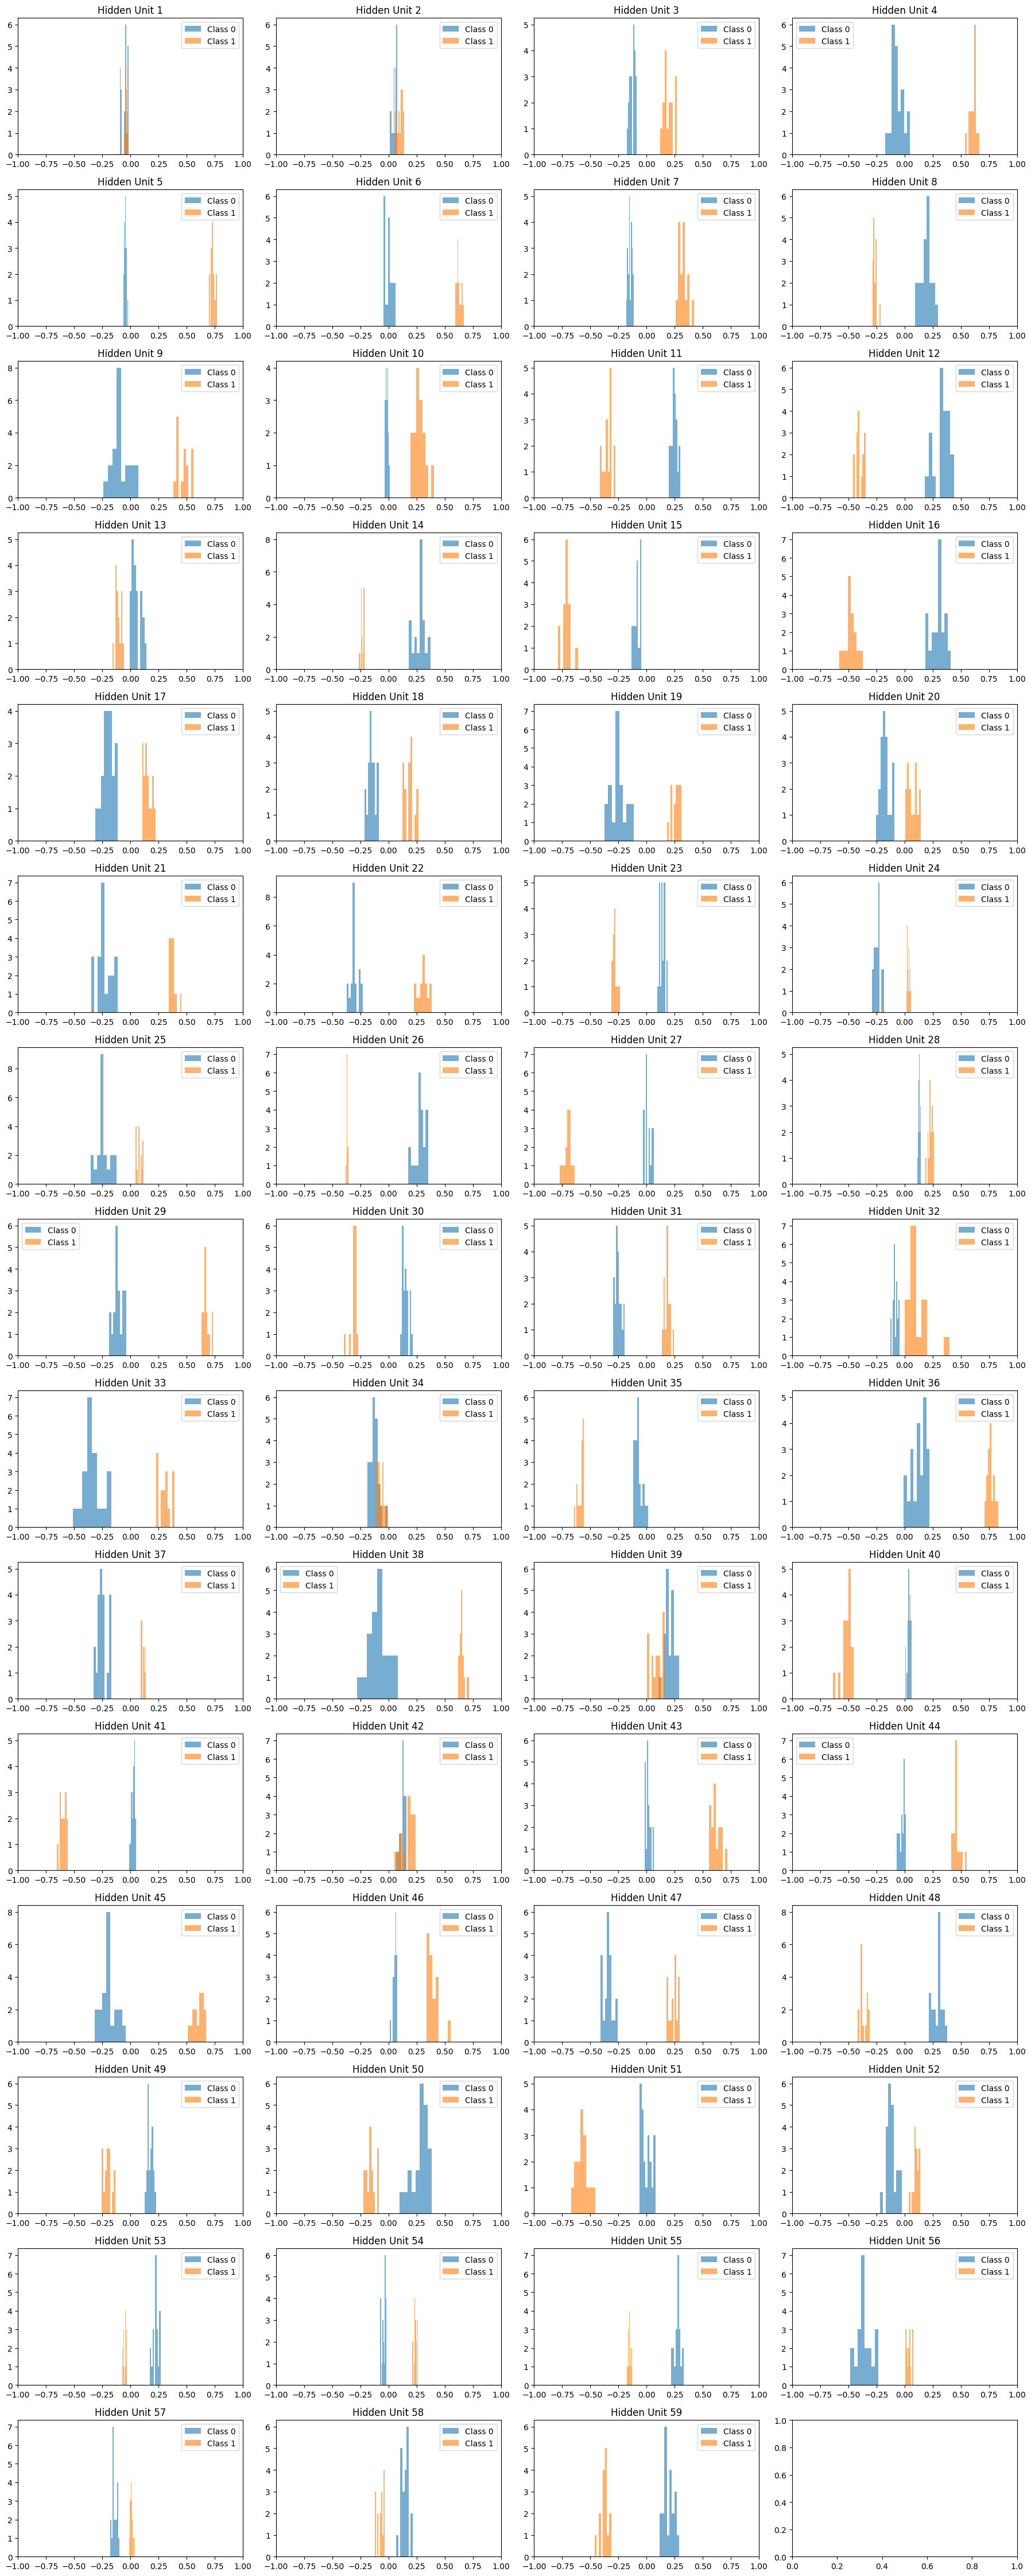

In [13]:
col_plots = 4
row_plots = int(np.ceil(npH.shape[2] / col_plots))

fig, ax = plt.subplots(row_plots, col_plots, figsize=(18, 45), squeeze=False)       # Add squeeze=False if displaying npL

epo = 49  # 8 Select which epoch to visualize
bins = int(np.ceil(np.sqrt(npH.shape[2])))      # Number of bins for histogram

x_max = np.max(npH)
x_min = np.min(npH)

for u in range(npH.shape[2]):
    # Boolean masks over batches
    mask0 = npY[epo, :] == 0
    mask1 = npY[epo, :] == 1

    # # Select hidden unit u for each class
    h0 = npH[epo, mask0, u]
    h1 = npH[epo, mask1, u]
    # print('h0 shape:', h0.shape, 'h1 shape:', h1.shape)
    # print("Class 0 std:", np.std(h0))
    # print("Class 1 std:", np.std(h1))

    r = u // col_plots
    c = u % col_plots
    ax[r, c].hist(h0, bins=bins, alpha=0.6, label="Class 0")
    ax[r, c].hist(h1, bins=bins, alpha=0.6, label="Class 1")
    ax[r, c].set_title(f'Hidden Unit {u+1}')
    ax[r, c].legend()
    ax[r, c].set_xlim(-1, 1)
    #ax[r, c].set_xlim([0, ])

plt.tight_layout()
plt.show()

[9.9997884e-01 2.1179630e-05]


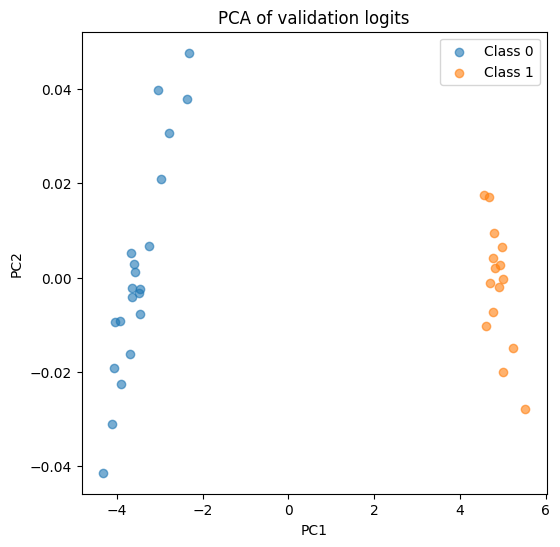

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

H_pca = pca.fit_transform(npL[epo, :, :])

print(pca.explained_variance_ratio_)

plt.figure(figsize=(6,6))
# npY[epo, :] == 0 - Takes all hidden features where class is 0
# H_pca[npY[epo, :]==0, 0] - Takes all PC1 values where class is 0
plt.scatter(H_pca[npY[epo, :]==0, 0], H_pca[npY[epo, :]==0, 1], alpha=0.6, label="Class 0")
plt.scatter(H_pca[npY[epo, :]==1, 0], H_pca[npY[epo, :]==1, 1], alpha=0.6, label="Class 1")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of validation logits")
plt.show()

## Model interference

### Re-create the model exactly the same

In [46]:
model_path = Path().resolve() / 'loggings/SingleNet_subject1_EMG_check_randomness/trial_2/model.pth'

checkpoint = torch.load(f = model_path, map_location = device)

model_interference = SingleNet(**checkpoint["model_args"])
model_interference.load_state_dict(checkpoint["model_state"])
model_interference.to(device)

SingleNet(
  (lstm): LSTM(3, 60, batch_first=True)
  (classifier): Sequential(
    (0): Linear(in_features=60, out_features=30, bias=True)
    (1): ELU(alpha=1.0)
    (2): Dropout(p=0.31266212985257863, inplace=False)
    (3): Linear(in_features=30, out_features=2, bias=True)
  )
)

In [47]:
inference_files = load_ins.find_flex_files(
                subjects = 'subject_0',
                modality = 'EMG',
                fingers = ['index', 'thumb'],
                prefix = 'flex'
)

EMG_inf, EMG_epoch_inf, EMG_epoch_mean_inf = load_ins.load_datasets_EMG(
    path_to_data_files = inference_files,
    preprocessing_func = EMG_ins.preprocessing_routine_rms,
    bandpass_lowcut = EMG_LOWCUT,
    bandpass_highcut = EMG_HIGHCUT,
    num_epochs = NUM_EPOCHS,
    trial_period = TRIAL_PERIOD,
    sample_window = RMS_SAMPLING_WINDOW,
    window_stepsize = RMS_WINDOW_STEPSIZE
)



--------------------------
Process to obtain RMS data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Did resample from 9597 to 9600

Total Time 240 s
Real fs: 39.9875 Hz
Target len: 9600
EMG original len: 480000
RMS len: 9600


--------------------------
Process to obtain RMS data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Did resample from 9597 to 9600

Total Time 240 s
Real fs: 39.9875 Hz
Target len: 9600
EMG original len: 480000
RMS len: 9600


--------------------------
Process to obtain RMS data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Did resample from 9597 to 9600

Total Time 240 s
Real fs: 39.9875 Hz
Target len: 9600
EMG original len: 480000
RMS len: 9600


--------------------------
Process to obtain RMS data
--------------------------

Trim 102 idx 6000
Trim 201 idx 486000
EMG_trim shape: (480000, 3)

Did resample from 9597

In [48]:
EMG_index_epoch_inf = EMG_epoch_inf[:90, :, :]
EMG_thumb_epoch_inf = EMG_epoch_inf[90:, :, :]

EMG_X_INF, labels_inf = None, None
EMG_X_INF = np.concatenate((EMG_index_epoch_inf, EMG_thumb_epoch_inf))
labels_inf = np.concatenate( (np.zeros(EMG_index_epoch_inf.shape[0]), np.ones(EMG_thumb_epoch_inf.shape[0])))

dataset_ins = SingleManageDataset(data = EMG_X_INF, labels = labels_inf)
rng = dataset_ins.get_rng_generator()

indices = rng.permutation(len(labels_inf))

inf_dataset = Subset(dataset_ins, indices)

inf_loader = DataLoader(inf_dataset, batch_size=16, shuffle=True, pin_memory=pin_memory, num_workers=0)

data shape: torch.Size([180, 320, 3])
labels shape: torch.Size([180])


### Evaluation loop

In [49]:
from sklearn.metrics import confusion_matrix

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in inf_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        logits, h = model_interference(inputs)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
print(cm)

cm_norm = cm / cm.sum(axis=1, keepdims=True)
print(cm_norm)

accuracy = correct / total
print(f"Test accuracy: {accuracy:.4f}")

[[90  0]
 [ 0 90]]
[[1. 0.]
 [0. 1.]]
Test accuracy: 1.0000


                    Predicted
               | Index  |  Thumb
              -----------------------
True  Index    |   TN   |   FP
True  Thumb    |   FN   |   TP

TN: Predicted index correct
FP: Predicted thumb, but was index
FN: Predicted index, but was thumb
TP: Predicted thumb correct